# Support Vector Machine (SVM) - Theory

Support Vector Machine (SVM) is a powerful supervised learning algorithm used for classification and regression tasks. It aims to find the optimal hyperplane that best separates the data into classes.

## 1. What is SVM?

SVM is a **margin-based classifier** that attempts to find the **maximum margin hyperplane** (MMH) which separates data points of different classes.

## 2. Key Concepts

### a. Hyperplane

A hyperplane is a decision boundary that separates data into different classes.

**Example (2D case):**

![Hyperplane](https://upload.wikimedia.org/wikipedia/commons/7/72/SVM_margin.png)

### b. Margin

Margin is the distance between the hyperplane and the nearest data point from either class. SVM tries to maximize this margin.

### c. Support Vectors

Support Vectors are the data points that lie closest to the decision boundary. They are critical in defining the position and orientation of the hyperplane.

### d. Linearly Separable Case

If data is linearly separable, SVM finds a straight line (or hyperplane in higher dimensions) that perfectly divides the classes.

![Linearly Separable](https://upload.wikimedia.org/wikipedia/commons/2/2a/SVM_Concept.png)

### e. Non-Linearly Separable Case

When data is not linearly separable, SVM uses a **kernel trick** to project the data into a higher-dimensional space where a hyperplane can separate the classes.

![Kernel Trick](https://upload.wikimedia.org/wikipedia/commons/8/88/SVM_Kernel_Example.svg)

## 3. Kernel Functions

Common kernels include:

- **Linear Kernel:** `K(x, y) = x^T y`
- **Polynomial Kernel:** `K(x, y) = (x^T y + c)^d`
- **RBF (Gaussian) Kernel:** `K(x, y) = exp(-γ||x - y||²)`

## 4. Cost Function (Soft Margin)

When perfect separation is not possible, SVM uses a **soft margin** and introduces a regularization parameter `C` to allow misclassification:

`minimize (1/2)||w||² + C Σ ξ_i`  
subject to: `y_i (w^T x_i + b) ≥ 1 - ξ_i`, where `ξ_i ≥ 0`

## 5. Advantages and Disadvantages

### Advantages:
- Effective in high-dimensional spaces
- Works well with clear margin of separation
- Memory efficient

### Disadvantages:
- Not suitable for large datasets
- Less effective when classes overlap significantly
- Choosing the right kernel and parameters is crucial

## 6. Applications

- Image classification
- Text categorization
- Bioinformatics (e.g., cancer classification)

In [3]:
# import basic liabraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import ML liabraries
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder



In [4]:
# load the data
df= pd.read_csv('svc.csv')
df.tail()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
7347,0.299665,-0.057193,-0.181233,-0.195387,0.039905,0.077078,-0.282301,0.043616,0.060410,0.210795,...,-0.880324,-0.190437,0.829718,0.206972,-0.425619,-0.791883,0.238604,0.049819,30,WALKING_UPSTAIRS
7348,0.273853,-0.007749,-0.147468,-0.235309,0.004816,0.059280,-0.322552,-0.029456,0.080585,0.117440,...,-0.680744,0.064907,0.875679,-0.879033,0.400219,-0.771840,0.252676,0.050053,30,WALKING_UPSTAIRS
7349,0.273387,-0.017011,-0.045022,-0.218218,-0.103822,0.274533,-0.304515,-0.098913,0.332584,0.043999,...,-0.304029,0.052806,-0.266724,0.864404,0.701169,-0.779133,0.249145,0.040811,30,WALKING_UPSTAIRS
7350,0.289654,-0.018843,-0.158281,-0.219139,-0.111412,0.268893,-0.310487,-0.068200,0.319473,0.101702,...,-0.344314,-0.101360,0.700740,0.936674,-0.589479,-0.785181,0.246432,0.025339,30,WALKING_UPSTAIRS
7351,0.351503,-0.012423,-0.203867,-0.269270,-0.087212,0.177404,-0.377404,-0.038678,0.229430,0.269013,...,-0.740738,-0.280088,-0.007739,-0.056088,-0.616956,-0.783267,0.246809,0.036695,30,WALKING_UPSTAIRS


In [7]:
# creating feature and target variable
X = df.drop('Activity', axis=1)
y = df['Activity']


In [8]:
# split the data into tarin and test
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
# scale the data
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [10]:
# create the model
model=SVC()
# fit the model
model.fit(x_train,y_train)


SVC()

In [11]:
# MAKE THE  prediction
y_pred= model.predict(x_test)
# evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# classification report
print("Classification Report:\n", classification_report(y_test, y_pred))
# plot confusion matrix
plt.figure(figsize=(10, 7))

Accuracy: 0.9782460910944936
Classification Report:
                     precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       280
           SITTING       0.94      0.95      0.95       262
          STANDING       0.96      0.94      0.95       276
           WALKING       1.00      1.00      1.00       247
WALKING_DOWNSTAIRS       0.99      1.00      1.00       206
  WALKING_UPSTAIRS       0.99      0.98      0.99       200

          accuracy                           0.98      1471
         macro avg       0.98      0.98      0.98      1471
      weighted avg       0.98      0.98      0.98      1471



<Figure size 1000x700 with 0 Axes>

<Figure size 1000x700 with 0 Axes>

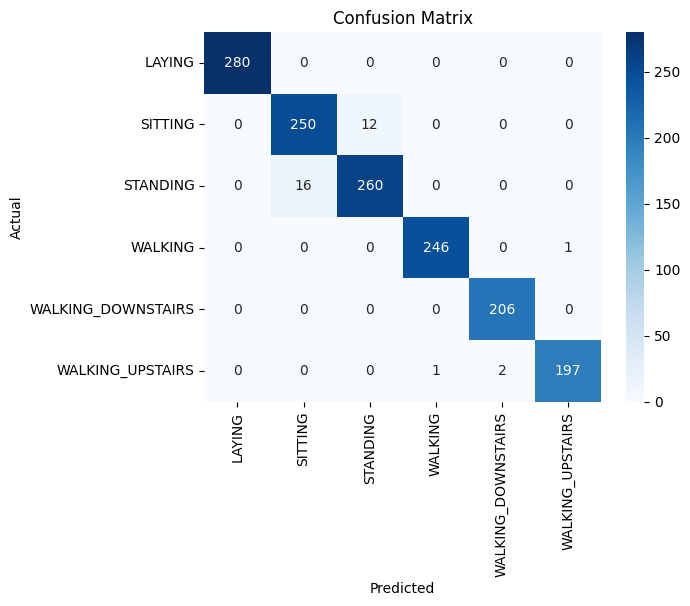

In [12]:
# plot the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [13]:
# save the model
import joblib
joblib.dump(model, 'svc_model.pkl')


['svc_model.pkl']

# testing the model on test.csv

In [15]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
import joblib  # to load saved model if needed

# 1. Load test data
test_df = pd.read_csv("test_svc.csv")

# 2. Split features and labels
X_test = test_df.drop("Activity", axis=1)  # Replace 'target' with your actual column name
y_test = test_df["Activity"]  # Replace 'target' with your actual column name

# 3. Preprocessing (e.g., scaling) – MUST be same as training!
# Example (only if you used scaler before)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)  # ❗ Use the same scaler as used during training (use .transform if reusing scaler)

#4. Load trained model or use directly if available
model = joblib.load("svc_model.pkl")  # If saved model


# 5. Make predictions
y_pred = model.predict(X_test_scaled)

# 6. Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9548693586698337
Classification Report:
                     precision    recall  f1-score   support

            LAYING       0.99      1.00      1.00       537
           SITTING       0.94      0.91      0.93       491
          STANDING       0.93      0.95      0.94       532
           WALKING       0.98      0.95      0.97       496
WALKING_DOWNSTAIRS       0.96      0.92      0.94       420
  WALKING_UPSTAIRS       0.93      0.99      0.96       471

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.96      0.95      0.95      2947



In [17]:
# now compare the both models accuracy  on train and test data
train_accuracy = accuracy_score(y_train, model.predict(x_train))
test_accuracy = accuracy_score(y_test, y_pred)
print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

# Save the model for future use
joblib.dump(model, 'svc_model.pkl')

Train Accuracy: 0.9870770277163747
Test Accuracy: 0.9548693586698337


['svc_model.pkl']